In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,5)

from scipy.integrate import solve_ivp

%matplotlib inline

## Allosteric activation

The reaction mechanism is as follows:
$$\begin{align*}
    A + E &\xrightleftharpoons[k_{-1}]{k_1} EA \\
    EA + S &\xrightleftharpoons[k_{-2}]{k_2} EAS \xrightarrow{k_3} P + EA 
\end{align*}
$$

Assuming that EA and EAdxdt[0] are in a quasi-steady-state, we find the following simplification of the governing ODEs to
$$\begin{align*}
    \dot{S(t)} &= -\frac{V_{max}S(t)A(t)}{K_1 + K_2A(t) + A(t)S(t)} \\
    \dot{P(t)} &= \frac{V_{max}S(t)A(t)}{K_1 + K_2A(t) + A(t)S(t)}
\end{align*},
$$
where $V_{max} = k_3 E_t$, $K_1 = \left[k_{-1}(k_{-2} + k_3)\right]/[k_1k_2]$, K_2 = [k_{-1} + k_3]/k_2.
Note that $E_t$ denotes the total enzyme concentration.

In [2]:
# define two sets of ODEs

# FULL SYSTEM
# p = [k_1, k_{-1}, k_2, k_{-2}, k_3, A, E_t]
# x = [S, EA, EAS,P]
def allo_activation_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[6] - x[1] - x[2] 
    dxdt[0] = -p[2]*x[1]*x[0] + p[3]*x[2]  #dSdt
    dxdt[1] =  p[0]*p[5]*E - p[1]*x[1] - p[2]*x[0]*x[1] + (p[3]+p[4])*x[2]  #dEAdt
    dxdt[2] = -p[3]*x[2] + p[2]*x[1]*x[0] - p[4]*x[2]  #dEASdt
    dxdt[3] =  p[4]*x[2]  #dPdt

    return dxdt


# REDUCED SYSTEM
# p = [Vmax, K_1, K_2, A]
# x = [S, P]
def allo_activation_reduced(t, x, p):
    dxdt = np.zeros(x.shape)

    dxdt[0] = -(p[0]*p[3]*x[0])/(p[1] + p[2]*p[3] + p[3]*x[0])  #dSdt
    dxdt[1] =  (p[0]*p[3]*x[0])/(p[1] + p[2]*p[3] + p[3]*x[0])  #dPdt

    return dxdt

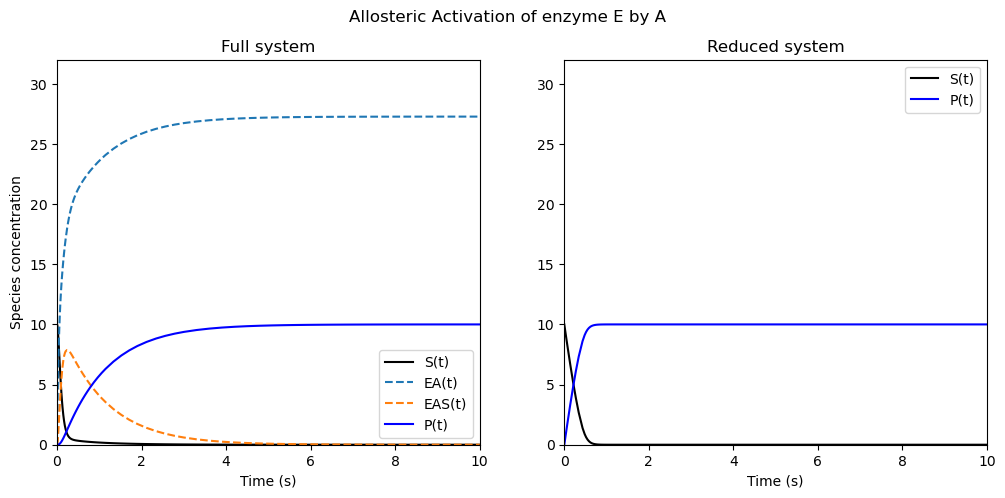

In [3]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
km2 = 1 #k_{-2}
k3 = 1
E_t = 30
A  = 2

Vmax = k3*E_t
K1 = (km1*(km2 + k3))/(k1*k2)
K2 = (km1 + k3)/k2

At = 10 # assume fixed activator concentration

p_full = np.array([k1, km1, k2, km2, k3, At, E_t])
p_reduced = np.array([Vmax, K1, K2, At])

# initial conditions
x0_full = np.array([10,0, 0, 0])
x0_reduced = np.array([10, 0])

# simulate
tspan = (0.0, 10.0)
x_sol_full = solve_ivp(allo_activation_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')
p_full_noA = np.array([k1, km1, k2, km2, k3, 0.1, E_t])
x_sol_full_noA = solve_ivp(allo_activation_full, tspan, x0_full, 
                            args=([p_full_noA]), method='BDF')
x_sol_reduced = solve_ivp(allo_activation_reduced, tspan, x0_reduced, 
                            args=([p_reduced]), method='BDF')

fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Full system')

ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[0], color='black')
ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[1], color='blue')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_xlabel('Time (s)')
ax[1].legend(['S(t)','P(t)'])
ax[1].set_title('Reduced system')
fig.suptitle('Allosteric Activation of enzyme E by A')

plt.savefig('../figures/test_enzyme_regulation_figs/allo_act.pdf', format='pdf')

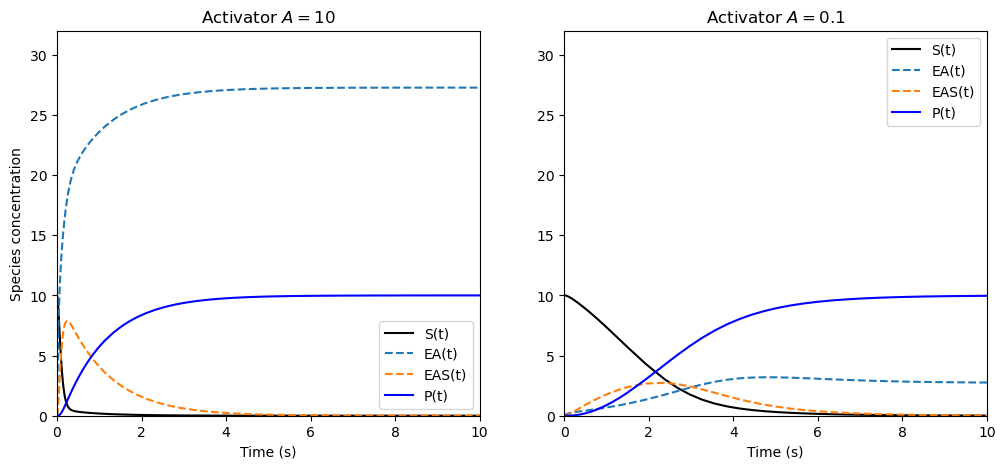

In [4]:
fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Activator $A=10$')

ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[0], color='black')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[1], '--')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[2], '--')
ax[1].plot(x_sol_full_noA.t, x_sol_full_noA.y[3], color='blue')
ax[1].legend(['S(t)','EA(t)', 'EAS(t)', 'P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_title('Activator $A = 0.1$')

plt.savefig('../figures/test_enzyme_regulation_figs/allo_act_test_act.pdf', format='pdf')

## Allosteric Inhibition

The reaction mechanism is as follows:
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
\end{align*}
$$

In [5]:
# define two sets of ODEs

# FULL SYSTEM
# p = [k_1, k_{-1}, k_2, k_3, k_{m3}, I, E_t]
# x = [S, ES, EI, ESI, P]
def allo_inhibition_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[6] - x[1] - x[2] - x[3]
    dxdt[0] = -p[0]*x[0]*E + p[1]*x[1]  #dSdt
    dxdt[1] =  p[0]*x[0]*E - (p[1]+p[2])*x[1] + (p[4]-p[3])*x[3]  #dESdt
    dxdt[2] =  p[3]*p[5]*E - p[4]*x[3] - p[0]*x[0]*x[2] + p[1]*x[3]  #dEIdt
    dxdt[3] =  p[3]*p[5]*x[1] - (p[4]+p[1])*x[3] + p[0]*x[0]*x[2]  #dESIdt
    dxdt[4] =  p[2]*x[1]  #dPdt

    return dxdt

# REDUCED SYSTEM
# TBD

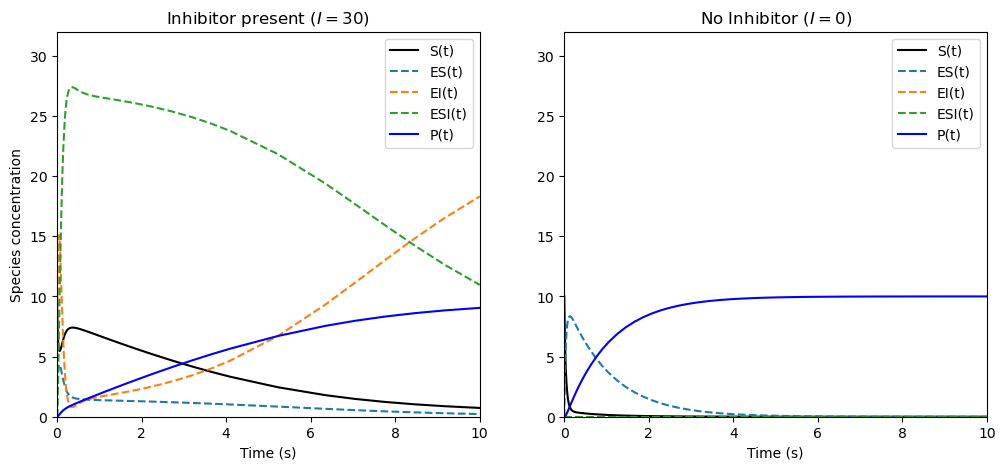

In [6]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
k3 = 1
km3 = 1
E_t = 30

It = 30 # assume fixed inhibitor concentration

p_full = np.array([k1, km1, k2, k3, km3, It, E_t])
# p_reduced = np.array([Vmax, K1, K2, At])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0])
# x0_reduced = np.array([10, 0])

# simulate
tspan = (0.0, 10.0)
p_full = np.array([k1, km1, k2, k3, km3, It, E_t])
x_sol_full = solve_ivp(allo_inhibition_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, k3, km3, 0, E_t])
x_sol_full_noI = solve_ivp(allo_inhibition_full, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')
# x_sol_reduced = solve_ivp(allo_activation_reduced, tspan, x0_reduced, 
                            # args=([p_reduced]), method='BDF')


fig, ax = plt.subplots(1,2)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[4], color='blue')
ax[0].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Inhibitor present ($I=30$)')

ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], color='black')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[1], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[2], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[3], '--')
ax[1].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], color='blue')
ax[1].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_title('No Inhibitor ($I=0$)')

plt.savefig('../figures/test_enzyme_regulation_figs/allo_inhibit.pdf', format='pdf')

## Inhibition of Allosteric Activation

The proposed reaction mechanism is as follows:
$$\begin{align*}
    A + E &\xrightleftharpoons[k_{-1}]{k_1} EA \\
    EA + S &\xrightleftharpoons[k_{-2}]{k_2} EAS \xrightarrow{k_3} P + EA \\
    I + E &\xrightleftharpoons[k_{-4}]{k_4} EI \\
    A + EI &\xrightleftharpoons[k_{-1}]{k_1} EAI \\
    I + EA &\xrightleftharpoons[k_{-4}]{k_4} EAI \\
    I + EAS &\xrightleftharpoons[k_{-4}]{k_4} EASI \\
    S + EAI &\xrightleftharpoons[k_{-2}]{k_2} EASI \\
\end{align*}
$$


In [7]:
# define ODE
# FULL SYSTEM
# p =[k_1, k_{-1}, k_2, k_{-2}, k_3, k_4, k_{-4}, I, A, E_t]
#       0   1       2   3       4     5     6     7   8  9
# x = [S, EA, EI, EAS, EAI, EASI, P]
#      0   1   2   3    4     5    6
def inhib_activ_full(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = -p[2]*x[1]*x[0] -p[2]*x[0]*x[4] + p[3]*x[3] + p[3]*x[5]  #dSdt
    dxdt[1] = (p[0]*p[8]*E - p[1]*x[1] - p[5]*p[7]*x[1] - p[2]*x[0]*x[1] + 
        p[3]*x[3] + p[4]*x[3] + p[6]*x[4])  #dEAdt
    dxdt[2] = p[5]*p[7]*E - p[6]*x[2] - p[0]*p[8]*x[2] + p[1]*x[4] #dEIdt
    dxdt[3] = p[2]*x[1]*x[0] - p[3]*x[3] - p[4]*x[3] - p[5]*p[7]*x[3] + p[6]*x[5]  #dEASdt
    dxdt[4] = (p[5]*p[7]*x[1] - p[6]*x[4] - p[2]*x[0]*x[4] - p[1]*x[4] + p[3]*x[5] 
        + p[0]*p[8]*x[2])  #dEAIdt
    dxdt[5] = p[5]*p[7]*x[3] - p[6]*x[5] - p[3]*x[5] + p[2]*x[0]*x[4]  #dEASIdt
    dxdt[6] = p[4]*x[3]  #dPdt

    return dxdt

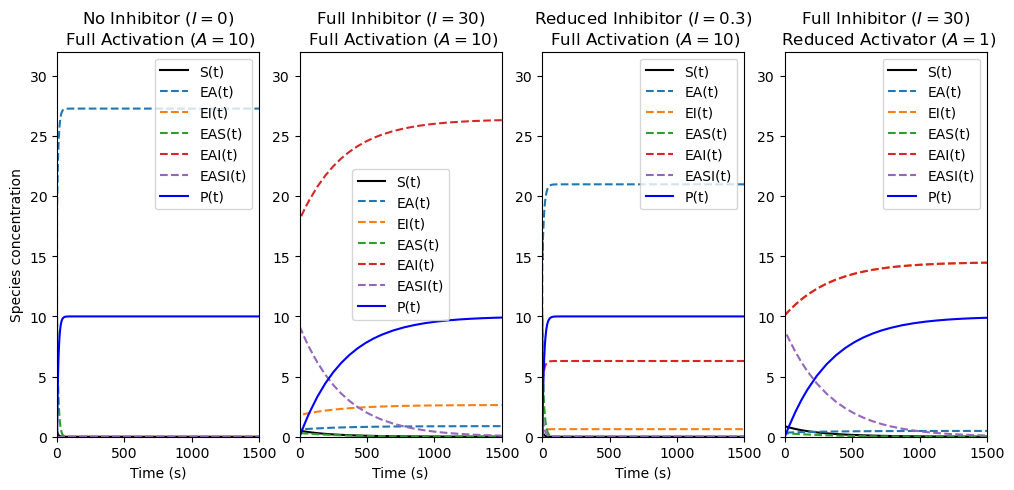

In [8]:
# define parameters
k1 = 10
km1 = 10  #k_{-1}
k2 = 10
km2 = 10
k3 = 0.1
k4 = 10
km4 = 10

E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
At = 10

p_full = np.array([k1, km1, k2, km2, k3, k4, km4, It, At, E_t])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0, 0, 0])

# simulate
tspan = (0.0, 1500.0)
x_sol_full = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, At, E_t])
x_sol_full_noI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')

p_full_redA = np.array([k1, km1, k2, km2, k3, k4, km4, It, 1, E_t])
x_sol_full_redA = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redA]), method='BDF')

p_full_redAnoI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, 0.1, E_t])
x_sol_full_redAnoI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redAnoI]), method='BDF')

p_full_redI = np.array([k1, km1, k2, km2, k3, k4, km4, 0.3, At, E_t])
x_sol_full_redI = solve_ivp(inhib_activ_full, tspan, x0_full, 
                            args=([p_full_redI]), method='BDF')


fig, ax = plt.subplots(1,4)
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], color='black')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[1], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[2], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[3], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[5], '--')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[6], color='blue')
ax[0].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, tspan[1]])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=10$)')

ax[1].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[1].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[1].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[1].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, tspan[1]])
ax[1].set_title('Full Inhibitor ($I = 30$)\n Full Activation ($A=10$)')

ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], color='black')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[1], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[2], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[3], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[4], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[5], '--')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[6], color='blue')
ax[2].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, tspan[1]])
ax[2].set_title('Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')

ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[0], color='black')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[1], '--')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[2], '--')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[3], '--')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[4], '--')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[5], '--')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[6], color='blue')
ax[3].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)', 'EAI(t)', 'EASI(t)','P(t)'])
ax[3].set_ylim([0, 32])
ax[3].set_xlim([0, tspan[1]])
ax[3].set_title('Full Inhibitor ($I = 30$)\n Reduced Activator ($A=1$)')

plt.savefig('../figures/test_enzyme_regulation_figs/inhibit_allo_act.pdf', format='pdf')


**Reduced Model Test**
See act_inhib_reducedODE.py for details and solve_inhib_actoi_20230109.nb for derivation

In [21]:
def inhib_activ_reduced(t, x, p):
    dxdt = np.zeros(x.shape)

    k1, r1, k2, r2, k3, k4, r4, Ii, At, Et=p

    denom = ((Ii*k4+r4)*(A**2*k1**2*(k3*(r2+r4+k2*x[0])+(r2+k2*x[0])*(Ii*k4+r2+r4+k2*x[0]))+A*k1*(2*k3*r1*r2+2*r1*r2**2+2*k3*r1*r4+k3*r2*r4+2*r1*r2*r4+r2**2*r4+k3*r4**2+r2*r4**2+k2*k3*r1*x[0]+2*k2*r1*r2*x[0]+k2*k3*r4*x[0]+k2*r1*r4*x[0]+2*k2*r2*r4*x[0]+k2*r4**2*x[0]+k2**2*r4*x[0]**2+Ii**2*k4**2*(r2+k2*x[0])+Ii*k4*(r1*(2*r2+k2*x[0])+k3*(r2+r4+k2*x[0])+(r2+k2*x[0])*(r2+2*r4+k2*x[0])))+r1*(Ii**2*k4**2*r2+(k3+r2)*(r1*(r2+r4)+r4*(r2+r4+k2*x[0]))+Ii*k4*(k3*(r2+r4)+r2*(r1+r2+2*r4+k2*x[0])))))**(-1)

    dxdt[0] = (-1)*A*Et*k1*k2*k3*r4*x[0]*(Ii**2*k4**2+r1*r2+r1*r4+r2*r4+r4**2+k2*r4*x[0]+A*k1*(Ii*k4+r2+r4+k2*x[0])+Ii*k4*(r1+r2+2*r4+k2*x[0]))*denom


    dxdt[1] = A*Et*k1*k2*k3*r4*x[0]*(Ii**2*k4**2+r1*r2+r1*r4+r2*r4+r4**2+k2*r4*x[0]+A*k1*(Ii*k4+r2+r4+k2*x[0])+Ii*k4*(r1+r2+2*r4+k2*x[0]))*denom

    return dxdt

def inhib_activ_newParams(t,x,p):
    dxdt = np.zeros(x.shape)
    
    Vmax, K1, K2, K3, Kd1, Kd2, Kd4, I, A=p

    dxdt[0] = -1*Vmax*A*x[0]*(I**2*Kd1*Kd2+A*(Kd4+(-1)*K3)*((-1)*Kd2*K2+(Kd4+(-1)*K2)*x[0])+I*(A*Kd2*((-1)*Kd4+K3)+Kd1*Kd2*(K2+K3)+Kd1*((-1)*Kd4+K2)*x[0])+Kd1*(Kd2*K2*K3+Kd4*((-1)*Kd4+K2)*x[0]))/((-1)*A**2*(Kd4+(-1)*K3)*(I*Kd2*(Kd2+x[0])+(K1+x[0])*(Kd2*K2+((-1)*Kd4+K2)*x[0]))+Kd1**2*(I**2*Kd2**2+Kd2*K1*K2*K3+Kd4*K1*((-1)*Kd4+K2)*x[0]+I*Kd2*(K1*K2+Kd2*K3+((-1)*Kd4+K2)*x[0]))+A*Kd1*(I**2*Kd2*(Kd2+x[0])+(-1)*(Kd4+(-1)*K2)*x[0]*(K1*K3+Kd4*x[0])+Kd2*K2*((-1)*Kd4*K1+2*K1*K3+K3*x[0])+I*(Kd2*K1*K2+(-1)*Kd2**2*(Kd4+(-2)*K3)+Kd2*(K2+K3)*x[0]+(-1)*(Kd4+(-1)*K2)*x[0]*(K1+x[0])))*(1+I*Kd4**(-1)))

    dxdt[1] = Vmax*A*x[0]*(I**2*Kd1*Kd2+A*(Kd4+(-1)*K3)*((-1)*Kd2*K2+(Kd4+(-1)*K2)*x[0])+I*(A*Kd2*((-1)*Kd4+K3)+Kd1*Kd2*(K2+K3)+Kd1*((-1)*Kd4+K2)*x[0])+Kd1*(Kd2*K2*K3+Kd4*((-1)*Kd4+K2)*x[0]))/((-1)*A**2*(Kd4+(-1)*K3)*(I*Kd2*(Kd2+x[0])+(K1+x[0])*(Kd2*K2+((-1)*Kd4+K2)*x[0]))+Kd1**2*(I**2*Kd2**2+Kd2*K1*K2*K3+Kd4*K1*((-1)*Kd4+K2)*x[0]+I*Kd2*(K1*K2+Kd2*K3+((-1)*Kd4+K2)*x[0]))+A*Kd1*(I**2*Kd2*(Kd2+x[0])+(-1)*(Kd4+(-1)*K2)*x[0]*(K1*K3+Kd4*x[0])+Kd2*K2*((-1)*Kd4*K1+2*K1*K3+K3*x[0])+I*(Kd2*K1*K2+(-1)*Kd2**2*(Kd4+(-2)*K3)+Kd2*(K2+K3)*x[0]+(-1)*(Kd4+(-1)*K2)*x[0]*(K1+x[0])))*(1+I*Kd4**(-1)))

    return dxdt

Text(0.5, 1.0, 'Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

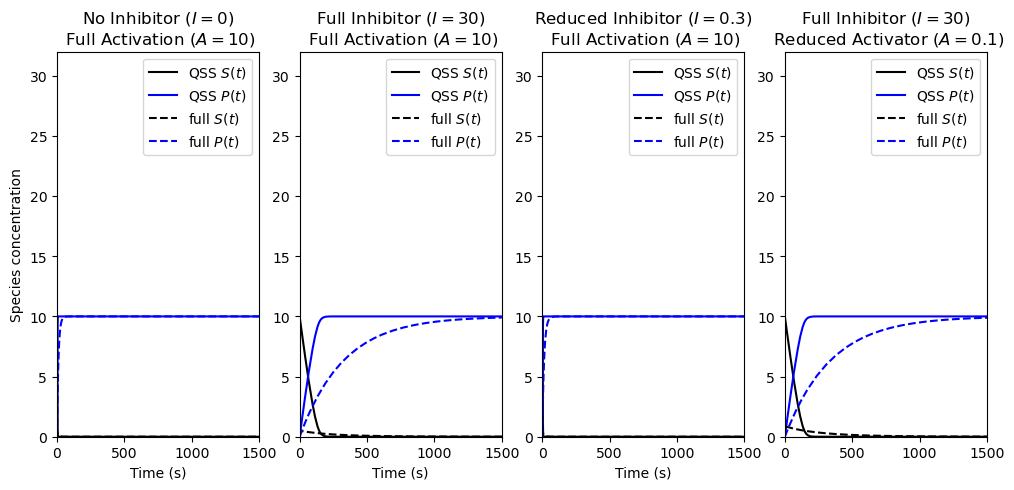

In [22]:
# simulate
x0_reduced = np.array([10,0])
x_sol_reduced = solve_ivp(inhib_activ_reduced, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, At, E_t])
x_sol_reduced_noI = solve_ivp(inhib_activ_reduced, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')

p_full_redA = np.array([k1, km1, k2, km2, k3, k4, km4, It, 0.1, E_t])
x_sol_reduced_redA = solve_ivp(inhib_activ_reduced, tspan, x0_full, 
                            args=([p_full_redA]), method='BDF')

p_full_redAnoI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, 0.1, E_t])
x_sol_reduced_redAnoI = solve_ivp(inhib_activ_reduced, tspan, x0_full, 
                            args=([p_full_redAnoI]), method='BDF')

p_full_redI = np.array([k1, km1, k2, km2, k3, k4, km4, 0.3, At, E_t])
x_sol_reduced_redI = solve_ivp(inhib_activ_reduced, tspan, x0_full, 
                            args=([p_full_redI]), method='BDF')


fig, ax = plt.subplots(1,4)
ax[0].plot(x_sol_reduced_noI.t, x_sol_reduced_noI.y[0], color='black')
ax[0].plot(x_sol_reduced_noI.t, x_sol_reduced_noI.y[1], color='blue')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], '--', color='black')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[6], '--', color='blue')
ax[0].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, tspan[1]])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=10$)')

ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[0], color='black')
ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[1], color='blue')
ax[1].plot(x_sol_full.t, x_sol_full.y[0], '--', color='black')
ax[1].plot(x_sol_full.t, x_sol_full.y[6], '--', color='blue')
ax[1].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, tspan[1]])
ax[1].set_title('Full Inhibitor ($I = 30$)\n Full Activation ($A=10$)')

ax[2].plot(x_sol_reduced_redI.t, x_sol_reduced_redI.y[0], color='black')
ax[2].plot(x_sol_reduced_redI.t, x_sol_reduced_redI.y[1], color='blue')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], '--', color='black')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[6], '--', color='blue')
ax[2].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, tspan[1]])
ax[2].set_title('Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')

ax[3].plot(x_sol_reduced_redA.t, x_sol_reduced_redA.y[0], color='black')
ax[3].plot(x_sol_reduced_redA.t, x_sol_reduced_redA.y[1], color='blue')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[0], '--', color='black')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[6], '--', color='blue')
ax[3].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[3].set_ylim([0, 32])
ax[3].set_xlim([0, tspan[1]])
ax[3].set_title('Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

Text(0.5, 1.0, 'Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

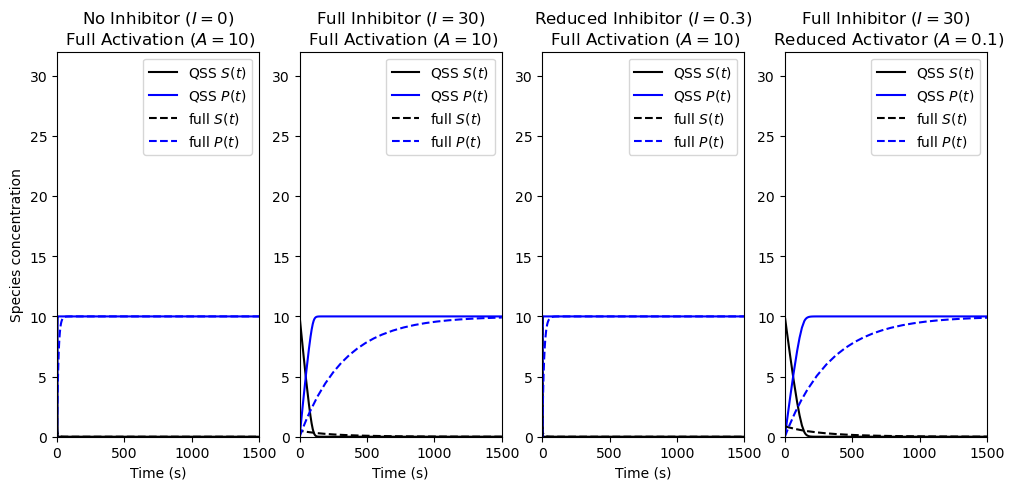

In [23]:
# simulate
Vmax = k3*E_t
K1 = (k3 + km2)/k2
K2 = (km2 + km4)/k4
K3 = (km1 + km4)/k4
Kd1 = km1/k1
Kd2 = km2/k2
Kd4 = km4/k4
p_reduced = np.array([Vmax, K1, K2, K3, Kd1, Kd2, Kd4, It, At])
x0_reduced = np.array([10,0])
x_sol_reduced = solve_ivp(inhib_activ_newParams, tspan, x0_full, 
                            args=([p_reduced]), method='BDF')

p_reduced_noI = np.array([Vmax, K1, K2, K3, Kd1, Kd2, Kd4, 0, At])
x_sol_reduced_noI = solve_ivp(inhib_activ_newParams, tspan, x0_full, 
                            args=([p_reduced_noI]), method='BDF')

p_reduced_redA = np.array([Vmax, K1, K2, K3, Kd1, Kd2, Kd4, It, 0.1])
x_sol_reduced_redA = solve_ivp(inhib_activ_newParams, tspan, x0_full, 
                            args=([p_reduced_redA]), method='BDF')

p_reduced_redAnoI = np.array([Vmax, K1, K2, K3, Kd1, Kd2, Kd4, 0, 0.1])
x_sol_reduced_redAnoI = solve_ivp(inhib_activ_newParams, tspan, x0_full, 
                            args=([p_reduced_redAnoI]), method='BDF')

p_reduced_redI = np.array([Vmax, K1, K2, K3, Kd1, Kd2, Kd4, 0.3, At])
x_sol_reduced_redI = solve_ivp(inhib_activ_newParams, tspan, x0_full, 
                            args=([p_reduced_redI]), method='BDF')


fig, ax = plt.subplots(1,4)
ax[0].plot(x_sol_reduced_noI.t, x_sol_reduced_noI.y[0], color='black')
ax[0].plot(x_sol_reduced_noI.t, x_sol_reduced_noI.y[1], color='blue')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], '--', color='black')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[6], '--', color='blue')
ax[0].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, tspan[1]])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=10$)')

ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[0], color='black')
ax[1].plot(x_sol_reduced.t, x_sol_reduced.y[1], color='blue')
ax[1].plot(x_sol_full.t, x_sol_full.y[0], '--', color='black')
ax[1].plot(x_sol_full.t, x_sol_full.y[6], '--', color='blue')
ax[1].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, tspan[1]])
ax[1].set_title('Full Inhibitor ($I = 30$)\n Full Activation ($A=10$)')

ax[2].plot(x_sol_reduced_redI.t, x_sol_reduced_redI.y[0], color='black')
ax[2].plot(x_sol_reduced_redI.t, x_sol_reduced_redI.y[1], color='blue')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], '--', color='black')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[6], '--', color='blue')
ax[2].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, tspan[1]])
ax[2].set_title('Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')

ax[3].plot(x_sol_reduced_redA.t, x_sol_reduced_redA.y[0], color='black')
ax[3].plot(x_sol_reduced_redA.t, x_sol_reduced_redA.y[1], color='blue')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[0], '--', color='black')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[6], '--', color='blue')
ax[3].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[3].set_ylim([0, 32])
ax[3].set_xlim([0, tspan[1]])
ax[3].set_title('Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

## Inhibition of Allosteric Activation without double binding

The proposed reaction mechanism is as follows:
$$\begin{align*}
    A + E &\xrightleftharpoons[k_{-1}]{k_1} EA \\
    EA + S &\xrightleftharpoons[k_{-2}]{k_2} EAS \xrightarrow{k_3} P + EA \\
    I + E &\xrightleftharpoons[k_{-4}]{k_4} EI
\end{align*}
$$


In [36]:
# define ODE
# FULL SYSTEM
# p =[k_1, k_{-1}, k_2, k_{-2}, k_3, k_4, k_{-4}, I, A, E_t]
#       0   1       2   3       4     5     6     7   8  9
# x = [S, EA, EI, EAS, P]
#      0  1   2   3    4
def inhib_activ_full_new(t, x, p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3]

    dxdt[0] = p[3]*x[3] - p[2]*x[1]*x[0] #dSdt
    dxdt[1] = p[0]*p[8]*E + (p[3]+p[4])*x[3] - p[1]*x[1] -p[2]*x[1]*x[0]  #dEAdt
    dxdt[2] = p[5]*p[7]*E - p[6]*x[2]  #dEIdt
    dxdt[3] = p[2]*x[1]*x[0] - (p[3]+p[4])*x[3]  #dEASdt
    dxdt[4] = p[4]*x[3]  #dPdt

    return dxdt


def inhib_activ_reduced_symbolic(t,x,p):
    dxdt = np.zeros(x.shape)

    S = x[0]
    P = x[1]

    k1,r1,k2,r2,k3,k4,r4,Ii,A,Et=p

    denom = (Ii*k4*r1*(k3+r2)+r1*(k3+r2)*r4+A*k1*r4*(k3+r2+k2*x[0]))**(-1)
    dxdt[0] = (-1)*A*Et*k1*k2*k3*r4*x[0]*denom
    dxdt[1] = A*Et*k1*k2*k3*r4*x[0]*denom

    return dxdt

(0.0, 1000.0)

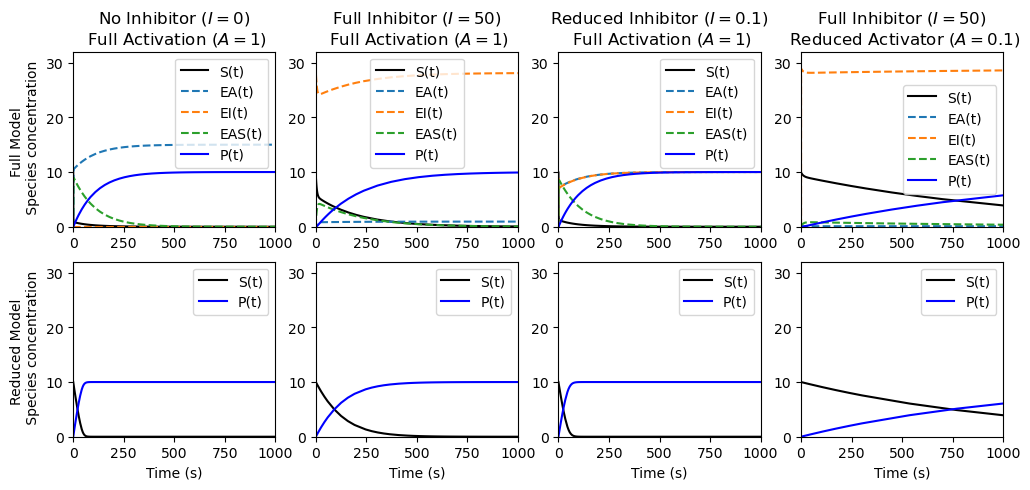

In [37]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 1
km2 = 1
k3 = 0.01
k4 = 1
km4 = 1


E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
At = 1

p_full = np.array([k1, km1, k2, km2, k3, k4, km4, It, At, E_t])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0])

# simulate
tspan = (0.0, 1000.0)
x_sol_full = solve_ivp(inhib_activ_full_new, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, At, E_t])
x_sol_full_noI = solve_ivp(inhib_activ_full_new, tspan, x0_full, 
                            args=([p_full_noI]), method='BDF')

p_full_redA = np.array([k1, km1, k2, km2, k3, k4, km4, It, 0.1, E_t])
x_sol_full_redA = solve_ivp(inhib_activ_full_new, tspan, x0_full, 
                            args=([p_full_redA]), method='BDF')

p_full_redAnoI = np.array([k1, km1, k2, km2, k3, k4, km4, 0, 0.1, E_t])
x_sol_full_redAnoI = solve_ivp(inhib_activ_full_new, tspan, x0_full, 
                            args=([p_full_redAnoI]), method='BDF')

p_full_redI = np.array([k1, km1, k2, km2, k3, k4, km4, 1, At, E_t])
x_sol_full_redI = solve_ivp(inhib_activ_full_new, tspan, x0_full, 
                            args=([p_full_redI]), method='BDF')

### Reduced system
# initial conditions
x0_red = np.array([10,0])

# simulate
tspan = (0.0, 1000.0)
x_sol_red = solve_ivp(inhib_activ_reduced_symbolic, tspan, x0_red, 
                            args=([p_full]), method='BDF')

x_sol_red_noI = solve_ivp(inhib_activ_reduced_symbolic, tspan, x0_red, 
                            args=([p_full_noI]), method='BDF')

x_sol_red_redA = solve_ivp(inhib_activ_reduced_symbolic, tspan, x0_red, 
                            args=([p_full_redA]), method='BDF')

x_sol_red_redAnoI = solve_ivp(inhib_activ_reduced_symbolic, tspan, x0_red, 
                            args=([p_full_redAnoI]), method='BDF')

x_sol_red_redI = solve_ivp(inhib_activ_reduced_symbolic, tspan, x0_red, 
                            args=([p_full_redI]), method='BDF')

# plot
fig, ax = plt.subplots(2,4)
ax[0][0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], color='black')
ax[0][0].plot(x_sol_full_noI.t, x_sol_full_noI.y[1], '--')
ax[0][0].plot(x_sol_full_noI.t, x_sol_full_noI.y[2], '--')
ax[0][0].plot(x_sol_full_noI.t, x_sol_full_noI.y[3], '--')
ax[0][0].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], color='blue')
ax[0][0].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)','P(t)'])
ax[0][0].set_ylim([0, 32])
ax[0][0].set_xlim([0, 1000])
ax[0][0].set_ylabel('Full Model \n Species concentration')
ax[0][0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=1$)')

ax[0][1].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0][1].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0][1].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0][1].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0][1].plot(x_sol_full.t, x_sol_full.y[4], color='blue')
ax[0][1].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)','P(t)'])
ax[0][1].set_ylim([0, 32])
ax[0][1].set_xlim([0, 1000])
ax[0][1].set_title('Full Inhibitor ($I = 50$)\n Full Activation ($A=1$)')

ax[0][2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], color='black')
ax[0][2].plot(x_sol_full_redI.t, x_sol_full_redI.y[1], '--')
ax[0][2].plot(x_sol_full_redI.t, x_sol_full_redI.y[2], '--')
ax[0][2].plot(x_sol_full_redI.t, x_sol_full_redI.y[3], '--')
ax[0][2].plot(x_sol_full_redI.t, x_sol_full_redI.y[4], color='blue')
ax[0][2].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)','P(t)'])
ax[0][2].set_ylim([0, 32])
ax[0][2].set_xlim([0, 1000])
ax[0][2].set_title('Reduced Inhibitor ($I = 0.1$)\n Full Activation ($A=1$)')

ax[0][3].plot(x_sol_full_redA.t, x_sol_full_redA.y[0], color='black')
ax[0][3].plot(x_sol_full_redA.t, x_sol_full_redA.y[1], '--')
ax[0][3].plot(x_sol_full_redA.t, x_sol_full_redA.y[2], '--')
ax[0][3].plot(x_sol_full_redA.t, x_sol_full_redA.y[3], '--')
ax[0][3].plot(x_sol_full_redA.t, x_sol_full_redA.y[4], color='blue')
ax[0][3].legend(['S(t)','EA(t)', 'EI(t)', 'EAS(t)','P(t)'])
ax[0][3].set_ylim([0, 32])
ax[0][3].set_xlim([0, 1000])
ax[0][3].set_title('Full Inhibitor ($I = 50$)\n Reduced Activator ($A=0.1$)')

ax[1][0].plot(x_sol_red_noI.t, x_sol_red_noI.y[0], color='black')
ax[1][0].plot(x_sol_red_noI.t, x_sol_red_noI.y[1], color='blue')
ax[1][0].legend(['S(t)','P(t)'])
ax[1][0].set_xlabel('Time (s)')
ax[1][0].set_ylim([0, 32])
ax[1][0].set_xlim([0, 1000])
ax[1][0].set_ylabel('Reduced Model \n Species concentration')

ax[1][1].plot(x_sol_red.t, x_sol_red.y[0], color='black')
ax[1][1].plot(x_sol_red.t, x_sol_red.y[1], color='blue')
ax[1][1].legend(['S(t)','P(t)'])
ax[1][1].set_xlabel('Time (s)')
ax[1][1].set_ylim([0, 32])
ax[1][1].set_xlim([0, 1000])

ax[1][2].plot(x_sol_red_redI.t, x_sol_red_redI.y[0], color='black')
ax[1][2].plot(x_sol_red_redI.t, x_sol_red_redI.y[1], color='blue')
ax[1][2].legend(['S(t)','P(t)'])
ax[1][2].set_xlabel('Time (s)')
ax[1][2].set_ylim([0, 32])
ax[1][2].set_xlim([0, 1000])

ax[1][3].plot(x_sol_red_redA.t, x_sol_red_redA.y[0], color='black')
ax[1][3].plot(x_sol_red_redA.t, x_sol_red_redA.y[1], color='blue')
ax[1][3].legend(['S(t)','P(t)'])
ax[1][3].set_xlabel('Time (s)')
ax[1][3].set_ylim([0, 32])
ax[1][3].set_xlim([0, 1000])


Text(0.5, 1.0, 'Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

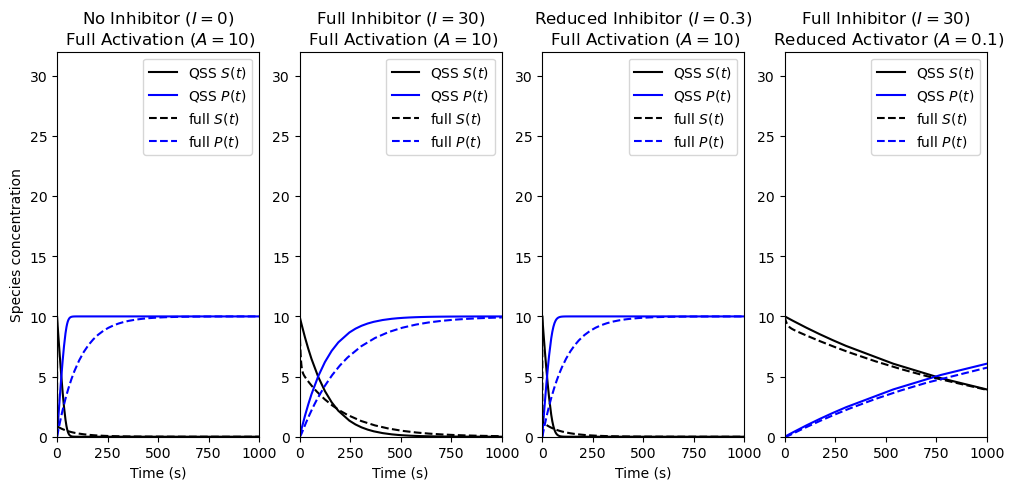

In [38]:
fig, ax = plt.subplots(1,4)
ax[0].plot(x_sol_red_noI.t, x_sol_red_noI.y[0], color='black')
ax[0].plot(x_sol_red_noI.t, x_sol_red_noI.y[1], color='blue')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[0], '--', color='black')
ax[0].plot(x_sol_full_noI.t, x_sol_full_noI.y[4], '--', color='blue')
ax[0].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, tspan[1]])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('No Inhibitor ($I=0$)\n Full Activation ($A=10$)')

ax[1].plot(x_sol_red.t, x_sol_red.y[0], color='black')
ax[1].plot(x_sol_red.t, x_sol_red.y[1], color='blue')
ax[1].plot(x_sol_full.t, x_sol_full.y[0], '--', color='black')
ax[1].plot(x_sol_full.t, x_sol_full.y[4], '--', color='blue')
ax[1].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, tspan[1]])
ax[1].set_title('Full Inhibitor ($I = 30$)\n Full Activation ($A=10$)')

ax[2].plot(x_sol_red_redI.t, x_sol_red_redI.y[0], color='black')
ax[2].plot(x_sol_red_redI.t, x_sol_red_redI.y[1], color='blue')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[0], '--', color='black')
ax[2].plot(x_sol_full_redI.t, x_sol_full_redI.y[4], '--', color='blue')
ax[2].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, tspan[1]])
ax[2].set_title('Reduced Inhibitor ($I = 0.3$)\n Full Activation ($A=10$)')

ax[3].plot(x_sol_red_redA.t, x_sol_red_redA.y[0], color='black')
ax[3].plot(x_sol_red_redA.t, x_sol_red_redA.y[1], color='blue')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[0], '--', color='black')
ax[3].plot(x_sol_full_redA.t, x_sol_full_redA.y[4], '--', color='blue')
ax[3].legend(['QSS $S(t)$','QSS $P(t)$', 'full $S(t)$', 'full $P(t)$'])
ax[3].set_ylim([0, 32])
ax[3].set_xlim([0, tspan[1]])
ax[3].set_title('Full Inhibitor ($I = 30$)\n Reduced Activator ($A=0.1$)')

## Inhibition of Allosteric Inhibition
### FAILED MECHANISMS!
Mechanism 1 is as follows:
Here the second inhibitor $R$ can replace the initial inhibitor $I$.
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
    E + R &\xrightleftharpoons[k_{-4}]{k_4} ER \\
    S + ER &\xrightleftharpoons[k_{-1}]{k_1} ERS \xrightarrow{k_2} P + ER \\
    R + EI &\xrightleftharpoons[k_{-4}]{k_4} ER + I\\
    R + ESI &\xrightleftharpoons[k_{-4}]{k_4} ERS + I\\
\end{align*}
$$

Mechanism 2 is as follows:
Here the second inhibitor $R$ only competes with the initial inhibitor $I$.
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
    E + R &\xrightleftharpoons[k_{-4}]{k_4} ER \\
    S + ER &\xrightleftharpoons[k_{-1}]{k_1} ERS \xrightarrow{k_2} P + ER \\
\end{align*}
$$

In [39]:
# define ODEs

# FULL SYSTEM 1
# p = [k_1, k_{-1}, k_2, k_3, k_{-3}, k_4, k_{-4}, I, R, E_t]
     # 0   1       2     3     4       5     6     7  8    9  
# x = [S, ES, EI, ER, ESI, ERS, P]
#       0  1   2    3   4   5   6
def inhib_inhib_m1_full(t,x,p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = p[1]*(x[1]+x[4]+x[5]) - p[0]*x[0]*(E+x[2]+x[3])           #dSdt
    dxdt[1] = p[0]*x[0]*E + p[4]*x[4] - x[1]*(p[1]+p[2]+p[3]*p[7])      #dESdt
    dxdt[2] = (p[3]*p[7]*E + p[1]*x[4] + p[6]*x[3]*p[7] - p[4]*x[2] 
                - p[0]*x[0]*x[2] - p[5]*p[8]*x[2])                      #dEIdt
    dxdt[3] = (p[5]*E*p[8] + (p[2]+p[1])*x[5] + p[5]*x[2]*p[8] - p[6]*x[3] 
                - p[0]*x[0]*x[3] - p[6]*x[3]*p[7])                      #dERdt
    dxdt[4] = (p[3]*p[7]*x[1] +  p[0]*x[0]*x[2] + p[6]*x[5]*p[7] 
                - (p[4]+p[1])*x[4] - p[5]*p[8]*x[4])                    #dESIdt
    dxdt[5] = (p[0]*x[0]*x[3] +  p[5]*p[8]*x[4] - (p[1]+p[2])*x[5] 
                - p[6]*x[5]*p[7])                                       #dERSdt
    dxdt[6] = p[2]*x[1] + p[2]*x[5]                                     #dPdt

    return dxdt


# reduced system 1
def inhib_inhib_m1_reduced(t,x,p):

    k1,r1,k2,k3,r3,k4,r4,Ii,R,Et=p

    dxdt = np.zeros(x.shape)

    denom = (k4**3*R**3*r1**2+k4**2*R**2*r1**3+2*k4**2*R**2*r1**2*r3+k4*R*r1**3*r3+k4*R*r1**2*r3**2+k4**3*R**3*r1*r4+3*k4**2*R**2*r1**2*r4+2*k4*R*r1**3*r4+2*k4**2*R**2*r1*r3*r4+5*k4*R*r1**2*r3*r4+2*r1**3*r3*r4+k4*R*r1*r3**2*r4+2*r1**2*r3**2*r4+2*k4**2*R**2*r1*r4**2+2*k4*R*r1**2*r4**2+4*k4*R*r1*r3*r4**2+2*r1**2*r3*r4**2+2*r1*r3**2*r4**2+k1*k4**3*R**3*r1*x[0]+2*k1*k4**2*R**2*r1**2*x[0]+2*k1*k4**2*R**2*r1*r3*x[0]+2*k1*k4*R*r1**2*r3*x[0]+k1*k4*R*r1*r3**2*x[0]+3*k1*k4**2*R**2*r1*r4*x[0]+4*k1*k4*R*r1**2*r4*x[0]+5*k1*k4*R*r1*r3*r4*x[0]+4*k1*r1**2*r3*r4*x[0]+2*k1*r1*r3**2*r4*x[0]+k1*k4**2*R**2*r4**2*x[0]+4*k1*k4*R*r1*r4**2*x[0]+4*k1*k4*R*r3*r4**2*x[0]+4*k1*r1*r3*r4**2*x[0]+2*k1*r3**2*r4**2*x[0]+k1**2*k4**2*R**2*r1*x[0]**2+k1**2*k4*R*r1*r3*x[0]**2+2*k1**2*k4*R*r1*r4*x[0]**2+2*k1**2*r1*r3*r4*x[0]**2+2*k1**2*k4*R*r4**2*x[0]**2+2*k1**2*r3*r4**2*x[0]**2+Ii**3*k3**2*k4*R*r4*((-1)*k4*R+(-2)*r4+k1*x[0])+k2**2*(k4**3*R**3+2*r3*r4*(r1+r3+k1*x[0])+k4**2*R**2*(r1+2*r3+2*r4+k1*x[0])+k4*R*(r3**2+4*r3*r4+r1*(r3+2*r4)+k1*r3*x[0]+3*k1*r4*x[0]))+k2*(k4**3*R**3*(2*r1+r4+k1*x[0])+2*r3*r4*(r1+r3+k1*x[0])*(2*r1+r4+k1*x[0])+k4**2*R**2*(2*r1+r4+k1*x[0])*(r1+2*r3+2*r4+k1*x[0])+k4*R*(2*r1**2*(r3+2*r4)+r3**2*(r4+k1*x[0])+k1*r4*x[0]*(3*r4+2*k1*x[0])+r1*(2*r3**2+9*r3*r4+2*r4**2+3*k1*r3*x[0]+7*k1*r4*x[0])+r3*(4*r4**2+5*k1*r4*x[0]+k1**2*x[0]**2)))+Ii**2*k3*((-1)*k4*R*r4*(k4**2*R**2+2*r1*r4+2*r3*r4+k4*R*(r1+r3+2*r4)+(-1)*k1*r1*x[0]+(-2)*k1*r3*x[0]+2*k1*r4*x[0]+(-1)*k1**2*x[0]**2)+k3*(2*r4*(r1+r4)*(r1+k1*x[0])+k4**2*R**2*(r1+r4+k1*x[0])+k4*R*(r1+2*r4)*(r1+r4+k1*x[0]))+k2*(k4*R*r4*((-1)*k4*R+(-2)*r4+k1*x[0])+k3*(k4**2*R**2+k4*R*(r1+2*r4)+2*r4*(r1+k1*x[0]))))+Ii*(k2**2*k3*(k4**2*R**2+k4*R*(r1+r3+2*r4)+2*r4*(r1+r3+k1*x[0]))+(-1)*k4*R*r4*(k4**2*R**2*r1+(-1)*k1*(r3+(-2)*r4)*x[0]*(r3+k1*x[0])+r1*(2*r3*r4+(-1)*k1*r3*x[0]+2*k1*r4*x[0])+k4*R*(r1*(r3+2*r4)+k1*((-1)*r3+r4)*x[0]))+k3*(2*r4*(r1+r4)*(r1+k1*x[0])*(r1+2*r3+k1*x[0])+k4**3*R**3*(r1+r4+k1*x[0])+k4**2*R**2*(r1+r4+k1*x[0])*(2*r1+r3+2*r4+k1*x[0])+k4*R*(r1**3+r1**2*(2*r3+5*r4+2*k1*x[0])+r1*(4*r3*r4+4*r4**2+2*k1*r3*x[0]+7*k1*r4*x[0]+k1**2*x[0]**2)+2*r4*(r3*(r4+k1*x[0])+k1*x[0]*(2*r4+k1*x[0]))))+k2*((-1)*k4*R*r4*(k4*R+2*r4+(-1)*k1*x[0])*(k4*R+r3+k1*x[0])+k3*(k4**3*R**3+k4**2*R**2*(3*r1+r3+3*r4+2*k1*x[0])+k4*R*(2*r1**2+r3*(3*r4+k1*x[0])+r1*(3*r3+7*r4+2*k1*x[0])+2*r4*(r4+3*k1*x[0]))+2*r4*(2*r1**2+k1*x[0]*(r4+k1*x[0])+r3*(r4+2*k1*x[0])+r1*(3*r3+r4+3*k1*x[0]))))))**(-1)


    dxdt[0] = Et*k1*x[0]*(Ii**3*k3**2*k4*R*r4*(k4*R+r1+2*r4)+(-1)*k4*R*r1*r4*(k4**2*R**2+r3*(r1+r3+k1*x[0])+k4*R*(r1+2*r3+r4+k1*x[0]))+(-1)*k2**2*(k4**3*R**3+2*r3*r4*(r1+r3+k1*x[0])+k4**2*R**2*(r1+2*r3+2*r4+k1*x[0])+k4*R*(r3**2+4*r3*r4+r1*(r3+r4)+k1*r3*x[0]+2*k1*r4*x[0]))+(-1)*k2*(r1+r4)*(k4**3*R**3+2*r3*r4*(r1+r3+k1*x[0])+k4**2*R**2*(r1+2*r3+2*r4+k1*x[0])+k4*R*(r3**2+4*r3*r4+r1*(r3+r4)+k1*r3*x[0]+2*k1*r4*x[0]))+Ii**2*k3*k4*R*((-1)*k2*(k3+(-1)*r4)*(k4*R+r1+2*r4)+r4*(k4**2*R**2+r1**2+2*r1*r3+2*r1*r4+2*r3*r4+(-1)*k3*(k4*R+r1+2*r4)+k1*r1*x[0]+2*k1*r4*x[0]+k4*R*(2*r1+r3+2*r4+k1*x[0])))+(-1)*Ii*(k2**2*k3*(k4**2*R**2+2*r3*r4+k4*R*(r1+r3+2*r4))+k4*R*r4*((-1)*r1*(k4**2*R**2+r3*(r1+r3+k1*x[0])+k4*R*(r1+2*r3+r4+k1*x[0]))+k3*(k4**2*R**2+r1**2+2*r4*(r3+k1*x[0])+k4*R*(2*r1+r3+2*r4+k1*x[0])+r1*(2*r3+2*r4+k1*x[0])))+k2*((-1)*k4*R*r4*(k4*R+r1+2*r4)*(k4*R+r3+k1*x[0])+k3*(k4**3*R**3+2*r3*r4*(r1+r4)+k4**2*R**2*(2*r1+r3+3*r4+k1*x[0])+k4*R*(r1**2+3*r3*r4+2*r4*(r4+k1*x[0])+r1*(2*r3+3*r4+k1*x[0]))))))*denom


    dxdt[1] = Et*k1*x[0]*(Ii**2*k3**2*k4*R*(r3*r4+k2*(k4*R+r1+2*r4))+k2**2*k4*R*(k4**2*R**2+r3*(r1+r3+k1*x[0])+k4*R*(r1+2*r3+r4+k1*x[0]))+k3*r4*(r1+r4)*(k4**2*R**2+2*r3*(r1+r3+k1*x[0])+k4*R*(r1+4*r3+2*k1*x[0]))+k2*(k4**3*R**3*r1+2*k3*r3*r4*(r1+r3+k1*x[0])+k4**2*R**2*(r1**2+k3*r4+r1*(2*r3+r4+k1*x[0]))+k4*R*(r1**2*r3+2*k3*r4*(2*r3+k1*x[0])+r1*(r3**2+k3*r4+k1*r3*x[0])))+Ii*k3*(k2**2*k4*R*(k4*R+r1+r3+2*r4)+r4*(k4**2*R**2*(r3+(-1)*r4)+2*k3*r3*(r1+r4)+k4*R*(r3**2+(-1)*k1*(r1+2*r4)*x[0]+r3*((-2)*r4+k1*x[0])))+k2*(k4**3*R**3+2*k3*r3*r4+k4**2*R**2*(2*r1+r3+2*r4+k1*x[0])+k4*R*(r1**2+2*r4*(r3+k1*x[0])+r1*(2*r3+2*r4+k1*x[0])))))*denom

    return dxdt

# FULL SYSTEM 2
# p = [k_1, k_{-1}, k_2, k_3, k_{-3}, I, R, E_t]
# x = [S, ES, EI, ER, ESI, ERS, P]
def inhib_inhib_m2_full(t,x,p):
    dxdt = np.zeros(x.shape)

    E = p[9] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = -(x[2]+E+x[3])*p[0]*x[0] + p[1]*(x[1]+x[4]+x[5])  #dSdt
    dxdt[1] = p[0]*x[0]*E - p[1]*x[1] - p[3]*p[7]*x[1] + p[4]*x[4]  #dESdt
    dxdt[2] = p[3]*p[7]*E - p[4]*x[2] - p[0]*x[0]*x[2] + p[1]*x[4]  #dEIdt
    dxdt[3] = p[5]*E*p[8] - p[6]*x[3] - p[0]*x[0]*x[3] + (p[1]+p[2])*x[5]  #dERdt
    dxdt[4] = p[3]*p[7]*x[1] - p[6]*x[3] - p[0]*x[0]*x[2] - p[1]*x[4]  #dESIdt
    dxdt[5] = p[0]*x[0]*x[3] - (p[1]+p[2])*x[5]  #dERSdt
    dxdt[6] = p[2]*(x[1]+x[5])

    return dxdt

Text(0.5, 1.05, 'FAILED: Inhibition of Inhibition: Full Mechanism 1')

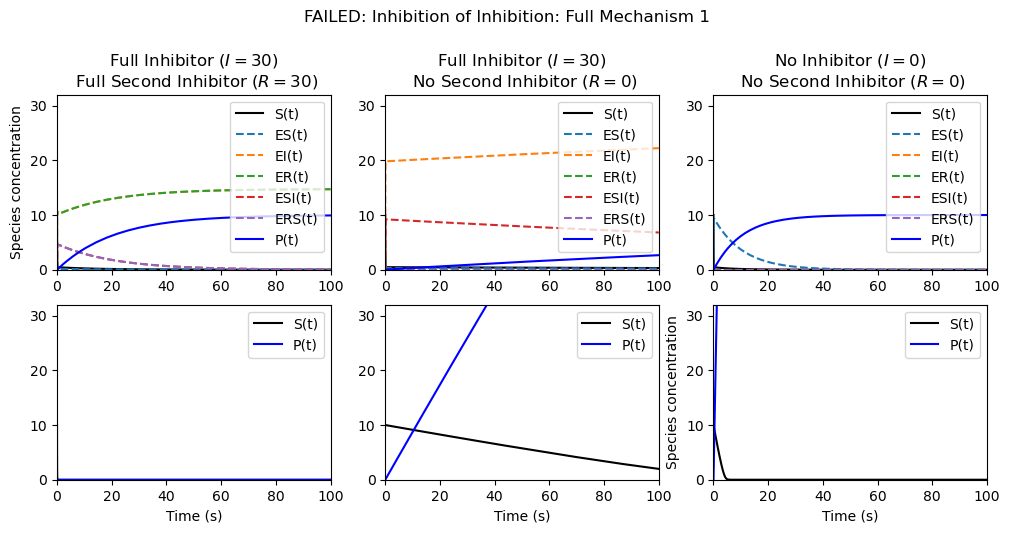

In [40]:
# define parameters
k1 = 1
km1 = 1  #k_{-1}
k2 = 0.1
k3 = 1
km3 = 1
k4 = 1
km4 = 1

E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
Rt = 30

p_full = np.array([k1, km1, k2, k3, km3, k4, km4, It, Rt, E_t])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0, 0, 0])
x0_red = np.array([10,0])

# simulate
tspan = (0.0, 100.0)
x_sol_full = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noR = np.array([k1, km1, k2, k3, km3, k4, km4, It, 0, E_t])
x_sol_full_noR = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI = np.array([k1, km1, k2, k3, km3, k4, km4, 0, 0, E_t])
x_sol_full_noRnoI = solve_ivp(inhib_inhib_m1_full, tspan, x0_full, 
                            args=([p_full_noRnoI]), method='BDF')

x_sol_red = solve_ivp(inhib_inhib_m1_reduced, tspan, x0_red, 
                            args=([p_full]), method='BDF')

p_full_noR = np.array([k1, km1, k2, k3, km3, k4, km4, It, 0, E_t])
x_sol_red_noR = solve_ivp(inhib_inhib_m1_reduced, tspan, x0_red, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI = np.array([k1, km1, k2, k3, km3, k4, km4, 0, 0, E_t])
x_sol_red_noRnoI = solve_ivp(inhib_inhib_m1_reduced, tspan, x0_red, 
                            args=([p_full_noRnoI]), method='BDF')

fig, ax = plt.subplots(2,3)
ax[0][0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[0][0].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0][0].set_ylim([0, 32])
ax[0][0].set_xlim([0, 100])
ax[0][0].set_ylabel('Species concentration')
ax[0][0].set_title('Full Inhibitor ($I = 30$)\n Full Second Inhibitor ($R=30$)')

ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[0], color='black')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[1], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[2], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[3], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[4], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[5], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[6], color='blue')
ax[0][1].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0][1].set_ylim([0, 32])
ax[0][1].set_xlim([0, 100])
ax[0][1].set_title('Full Inhibitor ($I = 30$)\n No Second Inhibitor ($R=0$)')

ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[0], color='black')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[1], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[2], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[3], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[4], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[5], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[6], color='blue')
ax[0][2].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0][2].set_ylim([0, 32])
ax[0][2].set_xlim([0, 100])
ax[0][2].set_title('No Inhibitor ($I = 0$)\n No Second Inhibitor ($R=0$)')

ax[1][0].plot(x_sol_red.t, x_sol_red.y[0], color='black')
ax[1][0].plot(x_sol_red.t, x_sol_red.y[1], color='blue')
ax[1][0].legend(['S(t)','P(t)'])
ax[1][0].set_xlabel('Time (s)')
ax[1][0].set_ylim([0, 32])
ax[1][0].set_xlim([0, 100])

ax[1][1].plot(x_sol_red_noR.t, x_sol_red_noR.y[0], color='black')
ax[1][1].plot(x_sol_red_noR.t, x_sol_red_noR.y[1], color='blue')
ax[1][1].legend(['S(t)','P(t)'])
ax[1][1].set_xlabel('Time (s)')
ax[1][1].set_ylim([0, 32])
ax[1][1].set_xlim([0, 100])

ax[1][2].plot(x_sol_red_noRnoI.t, x_sol_red_noRnoI.y[0], color='black')
ax[1][2].plot(x_sol_red_noRnoI.t, x_sol_red_noRnoI.y[1], color='blue')
ax[1][2].legend(['S(t)','P(t)'])
ax[1][2].set_xlabel('Time (s)')
ax[1][2].set_ylim([0, 32])
ax[1][2].set_xlim([0, 100])
ax[1][2].set_ylabel('Species concentration')
fig.suptitle('FAILED: Inhibition of Inhibition: Full Mechanism 1', y=1.05)

# plt.savefig('../figures/test_enzyme_regulation_figs/inhibit_allo_inhibit_m1.pdf', format='pdf')


Text(0.5, 1.05, 'FAILED: Inhibition of Inhibition: Full Mechanism 2')

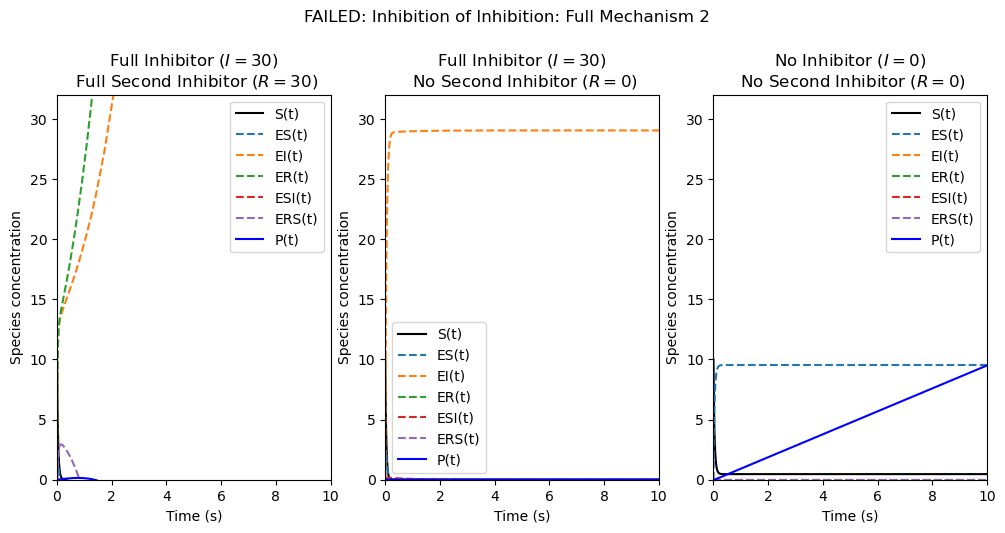

In [41]:
p_full = np.array([k1, km1, k2, k3, km3, k4, km4, It, Rt, E_t])
x_sol_full = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noR = np.array([k1, km1, k2, k3, km3, k4, km4, It, 0, E_t])
x_sol_full_noR = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI = np.array([k1, km1, k2, k3, km3, k4, km4, 0, 0, E_t])
x_sol_full_noRnoI = solve_ivp(inhib_inhib_m2_full, tspan, x0_full, 
                            args=([p_full_noRnoI]), method='BDF')


fig, ax = plt.subplots(1,3)
ax[0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[0].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[0].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[0].set_xlabel('Time (s)')
ax[0].set_ylim([0, 32])
ax[0].set_xlim([0, 10])
ax[0].set_ylabel('Species concentration')
ax[0].set_title('Full Inhibitor ($I = 30$)\n Full Second Inhibitor ($R=30$)')

ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[0], color='black')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[1], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[2], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[3], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[4], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[5], '--')
ax[1].plot(x_sol_full_noR.t, x_sol_full_noR.y[6], color='blue')
ax[1].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[1].set_xlabel('Time (s)')
ax[1].set_ylim([0, 32])
ax[1].set_xlim([0, 10])
ax[1].set_ylabel('Species concentration')
ax[1].set_title('Full Inhibitor ($I = 30$)\n No Second Inhibitor ($R=0$)')

ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[0], color='black')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[1], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[2], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[3], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[4], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[5], '--')
ax[2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[6], color='blue')
ax[2].legend(['S(t)','ES(t)', 'EI(t)', 'ER(t)', 'ESI(t)', 'ERS(t)','P(t)'])
ax[2].set_xlabel('Time (s)')
ax[2].set_ylim([0, 32])
ax[2].set_xlim([0, 10])
ax[2].set_ylabel('Species concentration')
ax[2].set_title('No Inhibitor ($I = 0$)\n No Second Inhibitor ($R=0$)')
fig.suptitle('FAILED: Inhibition of Inhibition: Full Mechanism 2', y=1.05)

# plt.savefig('../figures/test_enzyme_regulation_figs/inhibit_allo_inhibit_m2.pdf', format='pdf')

## Inhibition of Allosteric Inhibition
### GOOD Mechanism!
We can treat this as non-competitive inhibition and allosteric activation of the enzyme-inhibitor complex.

The proposed reaction mechanism is as follows.
Here the second inhibitor $R$ acts as an activator for $EI$ and $ESI$. 
$$\begin{align*}
    S + E &\xrightleftharpoons[k_{-1}]{k_1} ES \xrightarrow{k_2} P + E \\
    I + E &\xrightleftharpoons[k_{-3}]{k_3} EI \\
    I + ES &\xrightleftharpoons[k_{-3}]{k_3} ESI \\
    S + EI &\xrightleftharpoons[k_{-1}]{k_1} ESI \\
    R + EI &\xrightleftharpoons[k_{-4}]{k_4} REI \\
    R + ESI &\xrightleftharpoons[k_{-4}]{k_4} RESI \xrightarrow{k_2} P + REI \\
    REI + S &\xrightleftharpoons[k_{-1}]{k_1} RESI
\end{align*}
$$

This gives the differential equation
$$
\begin{align*}
    \dot{S}(t) &= k_{-1}ES(t) + k_{-1}ESI(t) + k_{-1}AESI(t) - k_1S(t)E(t) - k_1S(t)EI(t) - k_1S(t)AEI(t) \\
    \dot{ES}(t) &= k_1S(t)E(t) + k_{-3}ESI(t) - k_{-1}ES(t) - k_2ES(t) - k_3I(t)ES(t) \\
    \dot{EI}(t) &= k_3I(t)E(t) + k_{-1}ESI(t) + k_{-4}AEI(t) - k_{-3}EI(t) - k_1S(t)EI(t) - k_4A(t)EI(t) \\
    \dot{ESI}(t) &= k_3I(t)ES(t) + k_1S(t)EI(t) + k_{-4}AESI(t) - k_{-3}ESI(t) - k_4A(t)ESI(t) - k_{-1}ESI(t) \\
    \dot{AEI}(t) &= k_4A(t)EI(t) + k_2AESI(t) + k_{-1}AESI(t) - k_{-4}AEI(t) - k_1S(t)AEI(t) \\
    \dot{AESI}(t) &= k_4A(t)ESI(t) + k_1S(t)AEI(t) - k_{-4}AESI(t) - k_2AESI(t) - k_1AESI(t) \\
    \dot{P}(t) &= k_2ES(t) + k_2RESI(t)
\end{align*}
$$

<!-- The ODE has the stoichiometric matrix
$$
\begin{bmatrix}
-1 & 1 -1 & 1 & -1 & 1 \\

\end{bmatrix}
$$ -->

In [42]:
def inhib_inhib_full(t,x,p):
    dxdt = np.zeros(x.shape)

  
    k1, r1, k2, k3, r3, k4, r4,Et,A,I = p
    
    E = p[7] - x[1] - x[2] - x[3] - x[4] - x[5]

    dxdt[0] = r1*x[1] + r1*x[3] + r1*x[5] - k1*x[0]*E - k1*x[0]*x[2] - k1*x[0]*x[4]
    dxdt[1] = k1*x[0]*E + r3*x[3] - r1*x[1] - k2*x[1] - k3*I*x[1]
    dxdt[2] = k3*I*E + r1*x[3] + r4*x[4] - r3*x[2] - k1*x[0]*x[2] - k4*A*x[2]
    dxdt[3] = k3*I*x[1] + k1*x[0]*x[2] + r4*x[5] - r3*x[3] - k4*A*x[3] - r1*x[3]
    dxdt[4] = k4*A*x[2] + k2*x[5] + r1*x[5] - r4*x[4] - k1*x[0]*x[4]
    dxdt[5] = k4*A*x[3] + k1*x[0]*x[4] - r4*x[5] - k2*x[5] - k1*x[5]
    dxdt[6] = k2*x[1] + k2*x[5]


    return dxdt


def inhib_inhib_reduced(t,x,p):
    dxdt = np.zeros(x.shape)

  
    k1,r1,k2,k3,r3,k4,r4,Et,R,I = p
    
    denom = (k2**2*(k4*R+r1+r3+k1*x[0])+(r1+k1*x[0])*(k4*R*(r1+k1*x[0])+(r1+r3+k1*x[0])*(r1+r4+k1*x[0])+I*k3*(k4*R+r1+r4+k1*x[0]))+k2*(2*k4*R*(r1+k1*x[0])+I*k3*(k4*R+r1+k1*x[0])+(r1+r3+k1*x[0])*(2*r1+r4+2*k1*x[0])))**(-1)

    dxdt[0] = (-1)*Et*k1*k2*(r3*r4+I*k3*(k4*R+r4))**(-1)*x[0]*(I**2*k3**2*k4*R*(k4*R+r1+r4+k1*x[0])+r3*r4*(k4*R*(r1+k1*x[0])+k2*(k4*R+r1+r3+k1*x[0])+(r1+r3+k1*x[0])*(r1+r4+k1*x[0]))+I*k3*(k4**2*R**2*(r1+k1*x[0])+r3*r4*(r1+r4+k1*x[0])+k2*(k4**2*R**2+r3*r4+k4*R*(r1+r3+r4+k1*x[0]))+k4*R*(r1**2+k1*x[0]*(r4+k1*x[0])+r3*(2*r4+k1*x[0])+r1*(r3+r4+2*k1*x[0]))))*denom

    dxdt[1] = Et*k1*k2*(r3*r4+I*k3*(k4*R+r4))**(-1)*x[0]*(I**2*k3**2*k4*R*(k4*R+r1+r4+k1*x[0])+r3*r4*(k4*R*(r1+k1*x[0])+k2*(k4*R+r1+r3+k1*x[0])+(r1+r3+k1*x[0])*(r1+r4+k1*x[0]))+I*k3*(k4**2*R**2*(r1+k1*x[0])+r3*r4*(r1+r4+k1*x[0])+k2*(k4**2*R**2+r3*r4+k4*R*(r1+r3+r4+k1*x[0]))+k4*R*(r1**2+k1*x[0]*(r4+k1*x[0])+r3*(2*r4+k1*x[0])+r1*(r3+r4+2*k1*x[0]))))*denom        


    return dxdt

Text(0.5, 1.05, 'Inhibition of Inhibition')

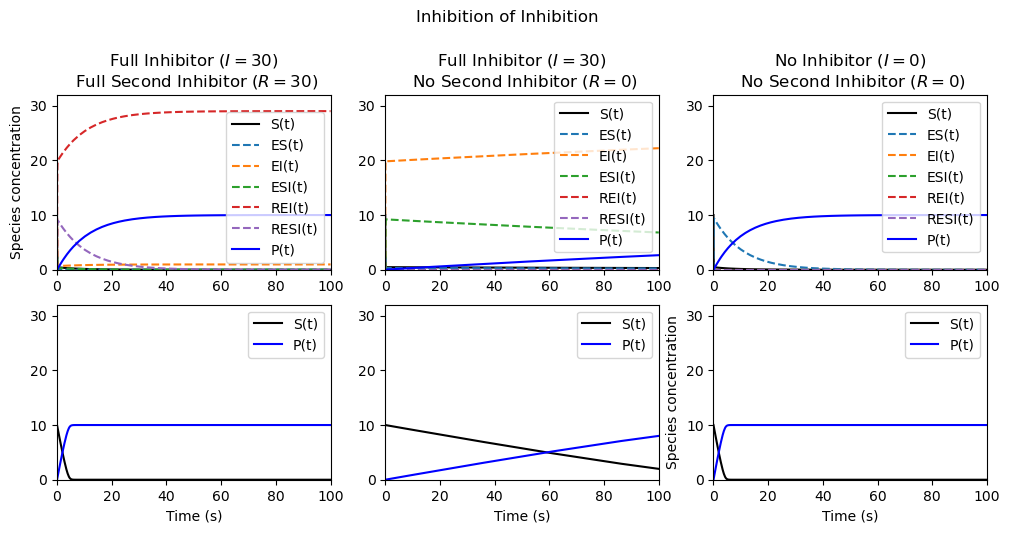

In [43]:
# define parameters
k1 = 1
r1 = 1  #k_{-1}
k2 = 0.1
k3 = 1
r3 = 1
k4 = 1
r4 = 1

E_t = 30

It = 30 # assume fixed activator/inhibitor concentration
Rt = 30

p_full = np.array([k1, r1, k2, k3, r3, k4, r4, E_t, Rt, It])

# initial conditions
x0_full = np.array([10,0, 0, 0, 0, 0, 0])
x0_red = np.array([10,0.001])

# simulate
tspan = (0.0, 100.0)
x_sol_full = solve_ivp(inhib_inhib_full, tspan, x0_full, 
                            args=([p_full]), method='BDF')

p_full_noR =  np.array([k1, r1, k2, k3, r3, k4, r4, E_t, 0, It])
x_sol_full_noR = solve_ivp(inhib_inhib_full, tspan, x0_full, 
                            args=([p_full_noR]), method='BDF')

p_full_noRnoI =  np.array([k1, r1, k2, k3, r3, k4, r4, E_t, 0, 0])
x_sol_full_noRnoI = solve_ivp(inhib_inhib_full, tspan, x0_full, 
                            args=([p_full_noRnoI]), method='BDF')

x_sol_red = solve_ivp(inhib_inhib_reduced, tspan, x0_red, 
                            args=([p_full]), method='BDF')

x_sol_red_noR = solve_ivp(inhib_inhib_reduced, tspan, x0_red, 
                            args=([p_full_noR]), method='BDF')

x_sol_red_noRnoI = solve_ivp(inhib_inhib_reduced, tspan, x0_red, 
                            args=([p_full_noRnoI]), method='BDF')

fig, ax = plt.subplots(2,3)
ax[0][0].plot(x_sol_full.t, x_sol_full.y[0], color='black')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[1], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[2], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[3], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[4], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[5], '--')
ax[0][0].plot(x_sol_full.t, x_sol_full.y[6], color='blue')
ax[0][0].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)', 'REI(t)', 'RESI(t)','P(t)'])
ax[0][0].set_ylim([0, 32])
ax[0][0].set_xlim([0, 100])
ax[0][0].set_ylabel('Species concentration')
ax[0][0].set_title('Full Inhibitor ($I = 30$)\n Full Second Inhibitor ($R=30$)')

ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[0], color='black')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[1], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[2], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[3], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[4], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[5], '--')
ax[0][1].plot(x_sol_full_noR.t, x_sol_full_noR.y[6], color='blue')
ax[0][1].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)', 'REI(t)', 'RESI(t)','P(t)'])
ax[0][1].set_ylim([0, 32])
ax[0][1].set_xlim([0, 100])
ax[0][1].set_title('Full Inhibitor ($I = 30$)\n No Second Inhibitor ($R=0$)')

ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[0], color='black')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[1], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[2], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[3], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[4], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[5], '--')
ax[0][2].plot(x_sol_full_noRnoI.t, x_sol_full_noRnoI.y[6], color='blue')
ax[0][2].legend(['S(t)','ES(t)', 'EI(t)', 'ESI(t)', 'REI(t)', 'RESI(t)','P(t)'])
ax[0][2].set_ylim([0, 32])
ax[0][2].set_xlim([0, 100])
ax[0][2].set_title('No Inhibitor ($I = 0$)\n No Second Inhibitor ($R=0$)')

ax[1][0].plot(x_sol_red.t, x_sol_red.y[0], color='black')
ax[1][0].plot(x_sol_red.t, x_sol_red.y[1], color='blue')
ax[1][0].legend(['S(t)','P(t)'])
ax[1][0].set_xlabel('Time (s)')
ax[1][0].set_ylim([0, 32])
ax[1][0].set_xlim([0, 100])

ax[1][1].plot(x_sol_red_noR.t, x_sol_red_noR.y[0], color='black')
ax[1][1].plot(x_sol_red_noR.t, x_sol_red_noR.y[1], color='blue')
ax[1][1].legend(['S(t)','P(t)'])
ax[1][1].set_xlabel('Time (s)')
ax[1][1].set_ylim([0, 32])
ax[1][1].set_xlim([0, 100])

ax[1][2].plot(x_sol_red_noRnoI.t, x_sol_red_noRnoI.y[0], color='black')
ax[1][2].plot(x_sol_red_noRnoI.t, x_sol_red_noRnoI.y[1], color='blue')
ax[1][2].legend(['S(t)','P(t)'])
ax[1][2].set_xlabel('Time (s)')
ax[1][2].set_ylim([0, 32])
ax[1][2].set_xlim([0, 100])
ax[1][2].set_ylabel('Species concentration')
fig.suptitle('Inhibition of Inhibition', y=1.05)